In [125]:
import wntr

wn = wntr.network.WaterNetworkModel()

# SOURCE
wn.add_reservoir(
    "Source",
    base_head=120
)


# JUNCTIONS
wn.add_junction("J1", base_demand=0.00, elevation=10)
wn.add_junction("J2", base_demand=0.00, elevation=12)
wn.add_junction("J3", base_demand=0.00, elevation=15)
wn.add_junction("J4", base_demand=0.00, elevation=18)


# CONSUMERS
wn.add_junction("Customer_A", base_demand=0.15, elevation=20)
wn.add_junction("Customer_B", base_demand=0.25, elevation=22)
wn.add_junction("Customer_C", base_demand=0.20, elevation=25)


# COORDINATES
coords = {
    "Source": (0,5),
    "J1": (4,5),
    "J2": (8,5),
    "J3": (4,1),
    "J4": (8,1),
    "Customer_A": (8,9),
    "Customer_B": (12,5),
    "Customer_C": (8,-3)
}

for node, coord in coords.items():
    wn.get_node(node).coordinates = coord


# PIPES
inch = 0.0254

wn.add_pipe(
    "P1",
    "Source",
    "J1",
    length=1000,
    diameter=25*inch,
    roughness=100
)

wn.add_pipe(
    "P2",
    "J1",
    "J2",
    length=1200,
    diameter=25*inch,
    roughness=100
)

wn.add_pipe(
    "P3",
    "J1",
    "J3",
    length=800,
    diameter=18*inch,
    roughness=100
)

wn.add_pipe(
    "P4",
    "J3",
    "J4",
    length=1000,
    diameter=14*inch,
    roughness=100
)

wn.add_pipe(
    "P5",
    "J2",
    "Customer_A",
    length=500,
    diameter=14*inch,
    roughness=100
)

wn.add_pipe(
    "P6",
    "J2",
    "Customer_B",
    length=600,
    diameter=18*inch,
    roughness=100
)

wn.add_pipe(
    "P7",
    "J4",
    "Customer_C",
    length=700,
    diameter=14*inch,
    roughness=100
)

wntr.network.io.write_inpfile(
    wn,
    "production_benchmark.inp"
)

print("Production benchmark INP generated.")


Production benchmark INP generated.


C:\Users\Jatin\AppData\Local\Temp\ipykernel_17888\1000430349.py:9: DeprecationWarning: wntr.network.WaterNetworkModel.get_graph is deprecated, use wntr.network.WaterNetworkModel.to_graph instead
  G = wn.get_graph()


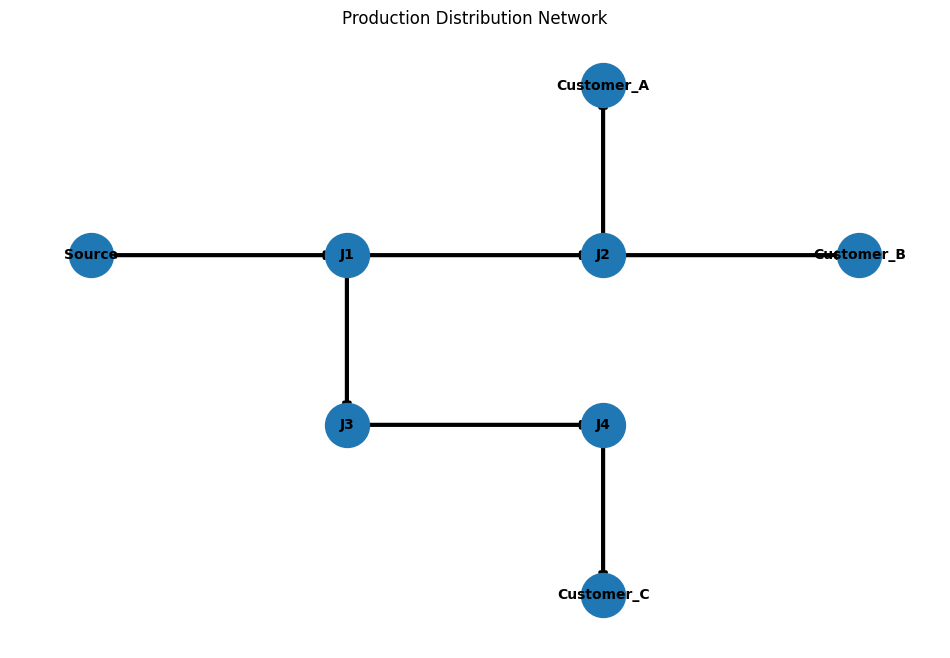

In [126]:
import wntr
import networkx as nx
import matplotlib.pyplot as plt

wn = wntr.network.WaterNetworkModel(
    "production_benchmark.inp"
)

G = wn.get_graph()

pos = {}

for node_name in wn.node_name_list:
    node = wn.get_node(node_name)
    pos[node_name] = node.coordinates

plt.figure(figsize=(12,8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1000
)

nx.draw_networkx_edges(
    G,
    pos,
    width=3
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

plt.title("Production Distribution Network")
plt.axis("off")
plt.show()

In [127]:
sim = wntr.sim.EpanetSimulator(wn)

results = sim.run_sim()

print("Simulation completed")

Simulation completed


In [128]:
pressure = results.node["pressure"]

pressure.iloc[-1]


name
J1            102.520699
J2             96.285027
J3             93.645836
J4             74.171478
Customer_A     83.450089
Customer_B     81.891701
Customer_C     55.639431
Source         -0.000004
Name: 0, dtype: float32

In [129]:
flow = results.link["flowrate"]

flow.iloc[-1]

name
P1    0.60
P2    0.40
P3    0.20
P4    0.20
P5    0.15
P6    0.25
P7    0.20
Name: 0, dtype: float32

In [130]:
velocity = results.link["velocity"]

velocity.iloc[-1]

name
P1    1.894585
P2    1.263057
P3    1.218226
P4    2.013802
P5    1.510352
P6    1.522782
P7    2.013802
Name: 0, dtype: float32

In [131]:
headloss = results.link["headloss"]

headloss.iloc[-1]

P1    0.007479
P2    0.003530
P3    0.004844
P4    0.016474
P5    0.009670
P6    0.007322
P7    0.016474
Name: 0, dtype: float32

In [132]:
print("\nPRESSURE")
print(results.node["pressure"].iloc[-1])

print("\nFLOW")
print(results.link["flowrate"].iloc[-1])

print("\nVELOCITY")
print(results.link["velocity"].iloc[-1])

print("\nHEADLOSS")
print(results.link["headloss"].iloc[-1])


PRESSURE
name
J1            102.520699
J2             96.285027
J3             93.645836
J4             74.171478
Customer_A     83.450089
Customer_B     81.891701
Customer_C     55.639431
Source         -0.000004
Name: 0, dtype: float32

FLOW
name
P1    0.60
P2    0.40
P3    0.20
P4    0.20
P5    0.15
P6    0.25
P7    0.20
Name: 0, dtype: float32

VELOCITY
name
P1    1.894585
P2    1.263057
P3    1.218226
P4    2.013802
P5    1.510352
P6    1.522782
P7    2.013802
Name: 0, dtype: float32

HEADLOSS
P1    0.007479
P2    0.003530
P3    0.004844
P4    0.016474
P5    0.009670
P6    0.007322
P7    0.016474
Name: 0, dtype: float32


Diameter Sensitivity Study

Objective

Study the effect of pipe diameter on

Pressure
Flow
Velocity
Headloss

Theory

Velocity

V = Q/A

A = πD²/4

Therefore

Diameter↓

Area↓

Velocity↑

------------------------

Headloss

Hazen Williams

hf = 10.67LQ^1.852 /
      (C^1.852 D^4.87)

Diameter↓

Headloss↑↑

Pressure↓


In [133]:
pipes = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7"
]

diameters = [
    25,
    22,
    20,
    18,
    16,
    14,
    12
]

inch = 0.0254

In [134]:
import copy
import pandas as pd

benchmark = []

for changed_pipe in pipes:

    print(f"Running {changed_pipe}")

    for d in diameters:

        wn_test = copy.deepcopy(wn)

        wn_test.get_link(changed_pipe).diameter = d * inch

        sim = wntr.sim.EpanetSimulator(wn_test)

        result = sim.run_sim()

        pressure = result.node["pressure"].iloc[-1]
        flow = result.link["flowrate"].iloc[-1]
        velocity = result.link["velocity"].iloc[-1]
        headloss = result.link["headloss"].iloc[-1]

        row = {

            "Changed_Pipe": changed_pipe,
            "Diameter": d

        }

        # -------------------------
        # PRESSURE
        # -------------------------

        for node in pressure.index:

            row[f"Pressure_{node}"] = pressure[node]

        # -------------------------
        # FLOW
        # -------------------------

        for pipe in flow.index:

            row[f"Flow_{pipe}"] = flow[pipe]

        # -------------------------
        # VELOCITY
        # -------------------------

        for pipe in velocity.index:

            row[f"Velocity_{pipe}"] = velocity[pipe]

        # -------------------------
        # HEADLOSS
        # -------------------------

        for pipe in headloss.index:

            row[f"Headloss_{pipe}"] = headloss[pipe]

        benchmark.append(row)

benchmark_df = pd.DataFrame(benchmark)

benchmark_df.head()

Running P1
Running P2
Running P3
Running P4
Running P5
Running P6
Running P7


,Changed_Pipe,Diameter,Pressure_J1,Pressure_J2,Pressure_J3,Pressure_J4,Pressure_Customer_A,Pressure_Customer_B,Pressure_Customer_C,Pressure_Source,...,Velocity_P5,Velocity_P6,Velocity_P7,Headloss_P1,Headloss_P2,Headloss_P3,Headloss_P4,Headloss_P5,Headloss_P6,Headloss_P7
0,P1,25,102.520699,96.285027,93.645836,74.171478,83.450089,81.891701,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
1,P1,22,96.059258,89.823601,87.184402,67.710045,76.988640,75.430252,49.177994,-0.000004,...,1.510352,1.522782,2.013802,0.013941,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
2,P1,20,87.822655,81.586990,78.947784,59.473431,68.752045,67.193649,40.941383,-0.000004,...,1.510352,1.522782,2.013802,0.022177,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
3,P1,18,72.949471,66.713821,64.074615,44.600254,53.878864,52.320477,26.068207,-0.000004,...,1.510352,1.522782,2.013802,0.037051,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
4,P1,16,44.240528,38.004868,35.365673,15.891315,25.169916,23.611530,-2.640737,-0.000004,...,1.510352,1.522782,2.013802,0.065759,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474


In [135]:
benchmark_df.shape

(49, 31)

In [136]:
p2 = benchmark_df[
    benchmark_df["Changed_Pipe"] == "P2"
]

p2

,Changed_Pipe,Diameter,Pressure_J1,Pressure_J2,Pressure_J3,Pressure_J4,Pressure_Customer_A,Pressure_Customer_B,Pressure_Customer_C,Pressure_Source,...,Velocity_P5,Velocity_P6,Velocity_P7,Headloss_P1,Headloss_P2,Headloss_P3,Headloss_P4,Headloss_P5,Headloss_P6,Headloss_P7
7,P2,25,102.520699,96.285027,93.645836,74.171478,83.450089,81.891701,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.003530,0.004844,0.016474,0.00967,0.007322,0.016474
8,P2,22,102.520699,92.625809,93.645836,74.171478,79.790855,78.232475,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.006579,0.004844,0.016474,0.00967,0.007322,0.016474
9,P2,20,102.520699,87.961273,93.645836,74.171478,75.126320,73.567932,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.010466,0.004844,0.016474,0.00967,0.007322,0.016474
10,P2,18,102.520699,79.538322,93.645836,74.171478,66.703377,65.144989,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.017485,0.004844,0.016474,0.00967,0.007322,0.016474
11,P2,16,102.520699,63.279938,93.645836,74.171478,50.444988,48.886600,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.031034,0.004844,0.016474,0.00967,0.007322,0.016474
12,P2,14,102.520699,29.153719,93.645836,74.171478,16.318771,14.760386,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.059472,0.004844,0.016474,0.00967,0.007322,0.016474
13,P2,12,102.520699,-50.694386,93.645836,74.171478,-63.529335,-65.087723,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.126013,0.004844,0.016474,0.00967,0.007322,0.016474


In [ ]:
p5 = benchmark_df[
    benchmark_df["Changed_Pipe"] == "P4"
]

p5

,Changed_Pipe,Diameter,Pressure_J1,Pressure_J2,Pressure_J3,Pressure_J4,Pressure_Customer_A,Pressure_Customer_B,Pressure_Customer_C,Pressure_Source,...,Velocity_P5,Velocity_P6,Velocity_P7,Headloss_P1,Headloss_P2,Headloss_P3,Headloss_P4,Headloss_P5,Headloss_P6,Headloss_P7
28,P5,25,102.520699,96.285027,93.645836,74.171478,87.998085,81.891701,55.639431,-0.000004,...,0.473646,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.000574,0.007322,0.016474
29,P5,22,102.520699,96.285027,93.645836,74.171478,87.750175,81.891701,55.639431,-0.000004,...,0.611630,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.001070,0.007322,0.016474
30,P5,20,102.520699,96.285027,93.645836,74.171478,87.434166,81.891701,55.639431,-0.000004,...,0.740072,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.001702,0.007322,0.016474
31,P5,18,102.520699,96.285027,93.645836,74.171478,86.863525,81.891701,55.639431,-0.000004,...,0.913669,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.002843,0.007322,0.016474
32,P5,16,102.520699,96.285027,93.645836,74.171478,85.762062,81.891701,55.639431,-0.000004,...,1.156363,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.005046,0.007322,0.016474
33,P5,14,102.520699,96.285027,93.645836,74.171478,83.450089,81.891701,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.009670,0.007322,0.016474
34,P5,12,102.520699,96.285027,93.645836,74.171478,78.040558,81.891701,55.639431,-0.000004,...,2.055756,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.020489,0.007322,0.016474


In [138]:
benchmark_df.to_csv(
    "diameter_sensitivity_benchmark.csv",
    index=False
)

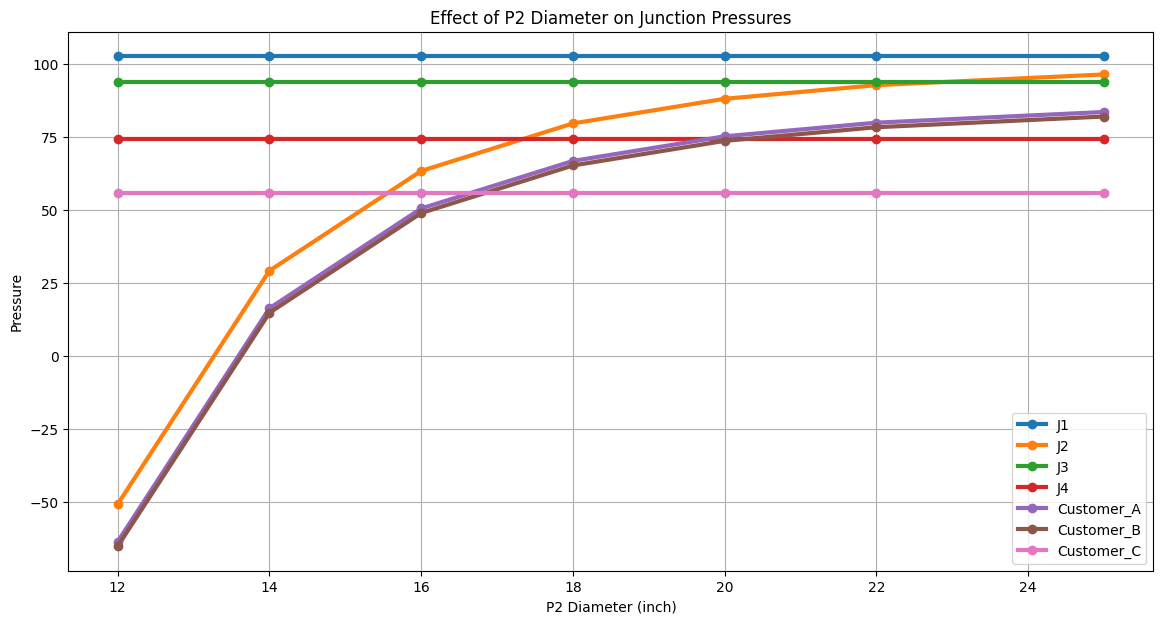

In [143]:
p2 = benchmark_df[
    benchmark_df["Changed_Pipe"] == "P2"
]

plt.figure(figsize=(14,7))

pressure_nodes = [
    "Pressure_J1",
    "Pressure_J2",
    "Pressure_J3",
    "Pressure_J4",
    "Pressure_Customer_A",
    "Pressure_Customer_B",
    "Pressure_Customer_C"
]

for node in pressure_nodes:

    plt.plot(
        p2["Diameter"],
        p2[node],
        marker="o",
        linewidth=3,
        label=node.replace("Pressure_","")
    )

plt.title("Effect of P2 Diameter on Junction Pressures")

plt.xlabel("P2 Diameter (inch)")

plt.ylabel("Pressure")

plt.grid(True)

plt.legend()

plt.show()

• J2 pressure decreases significantly.

• Customer_A pressure decreases.

• Customer_B pressure decreases.

• J3, J4 and Customer_C remain almost unchanged.

Reason:
P2 only feeds the J2 branch.

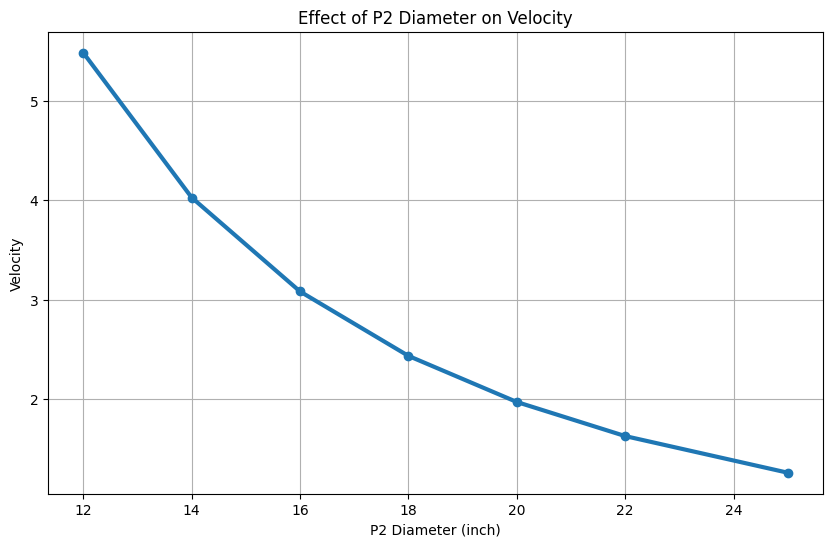

In [144]:
p2 = benchmark_df[
    benchmark_df["Changed_Pipe"]=="P2"
]

plt.figure(figsize=(10,6))

plt.plot(
    p2["Diameter"],
    p2["Velocity_P2"],
    marker="o",
    linewidth=3
)

plt.title("Effect of P2 Diameter on Velocity")

plt.xlabel("P2 Diameter (inch)")

plt.ylabel("Velocity")

plt.grid(True)

plt.show()

Diameter ↓

↓

Area ↓

↓

Velocity ↑

Exactly follows

V = Q/A

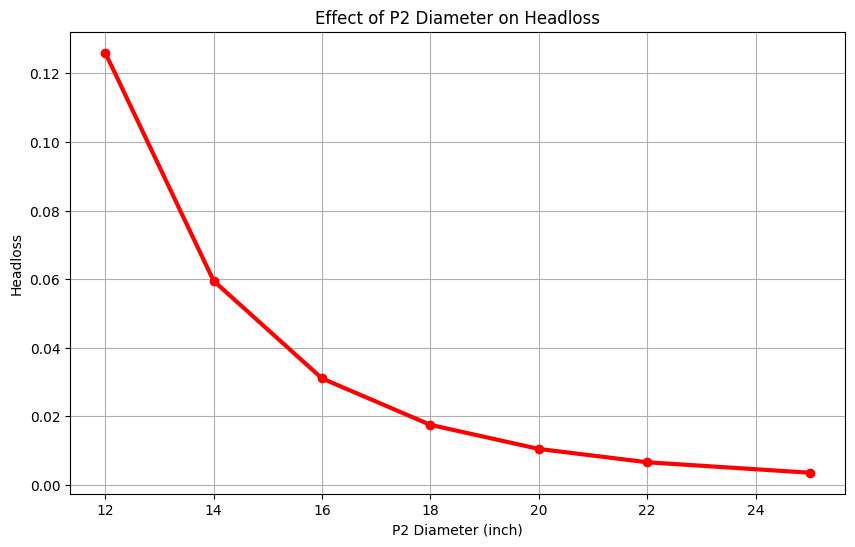

In [145]:
plt.figure(figsize=(10,6))

plt.plot(
    p2["Diameter"],
    p2["Headloss_P2"],
    marker="o",
    linewidth=3,
    color="red"
)

plt.title("Effect of P2 Diameter on Headloss")

plt.xlabel("P2 Diameter (inch)")

plt.ylabel("Headloss")

plt.grid(True)

plt.show()

Diameter decreases

↓

Headloss increases rapidly.

This follows the Hazen–Williams equation:

hf ∝ 1/D^4.87

The relationship is nonlinear.

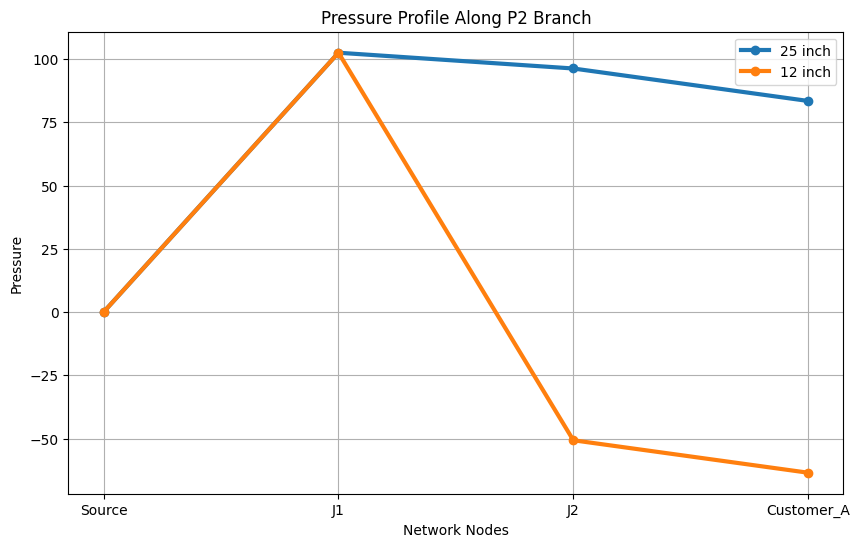

In [146]:
baseline = benchmark_df[
    (benchmark_df["Changed_Pipe"]=="P2") &
    (benchmark_df["Diameter"]==25)
].iloc[0]

small = benchmark_df[
    (benchmark_df["Changed_Pipe"]=="P2") &
    (benchmark_df["Diameter"]==12)
].iloc[0]

nodes = [
    "Source",
    "J1",
    "J2",
    "Customer_A"
]

baseline_pressure = [
    baseline["Pressure_Source"],
    baseline["Pressure_J1"],
    baseline["Pressure_J2"],
    baseline["Pressure_Customer_A"]
]

small_pressure = [
    small["Pressure_Source"],
    small["Pressure_J1"],
    small["Pressure_J2"],
    small["Pressure_Customer_A"]
]

plt.figure(figsize=(10,6))

plt.plot(
    nodes,
    baseline_pressure,
    marker="o",
    linewidth=3,
    label="25 inch"
)

plt.plot(
    nodes,
    small_pressure,
    marker="o",
    linewidth=3,
    label="12 inch"
)

plt.title("Pressure Profile Along P2 Branch")

plt.xlabel("Network Nodes")

plt.ylabel("Pressure")

plt.grid(True)

plt.legend()

plt.show()

Pressure decreases gradually from Source to Customer.

When P2 diameter becomes smaller,

the pressure drop between J1 and J2 increases significantly.

Most of the energy loss occurs across P2.

Downstream nodes receive much lower pressure.

This confirms that reducing pipe diameter increases hydraulic resistance.

## Engineering Observations

### Flow

Flow remained constant throughout all simulations.

Reason:
The EPANET model uses Demand-Driven Analysis (DDA). Customer demands are fixed, so changing pipe diameter does not alter the required flow. Instead, the hydraulic solver adjusts pressure to satisfy the demand.

---

### Pressure

Pressure decreased as pipe diameter decreased.

The largest pressure drop occurred downstream of the modified pipe because hydraulic resistance increased.

---

### Velocity

Velocity increased as diameter decreased.

This agrees with

V = Q / A

where reducing the pipe area increases flow velocity for the same discharge.

---

### Headloss

Headloss increased rapidly for smaller diameters.

The trend follows the Hazen–Williams equation

hf ∝ 1 / D^4.87

which predicts a nonlinear increase in friction losses.

---

### Hydraulic Behaviour

Changing a pipe mainly affects the downstream branch supplied by that pipe.

This demonstrates hydraulic influence zones within the network.